In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/house_prices.csv')
print(df.head())
print(df.shape)
print(df.columns)

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [2]:
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']
target = 'price'

df_clean = df[features + [target]]
print(df_clean.head())
print(df_clean.isnull().sum())

   bedrooms  bathrooms  sqft_living  sqft_lot  floors      price
0       3.0       1.50         1340      7912     1.5   313000.0
1       5.0       2.50         3650      9050     2.0  2384000.0
2       3.0       2.00         1930     11947     1.0   342000.0
3       3.0       2.25         2000      8030     1.0   420000.0
4       4.0       2.50         1940     10500     1.0   550000.0
bedrooms       0
bathrooms      0
sqft_living    0
sqft_lot       0
floors         0
price          0
dtype: int64


In [3]:
print(df_clean.describe())

          bedrooms    bathrooms   sqft_living      sqft_lot       floors  \
count  4600.000000  4600.000000   4600.000000  4.600000e+03  4600.000000   
mean      3.400870     2.160815   2139.346957  1.485252e+04     1.512065   
std       0.908848     0.783781    963.206916  3.588444e+04     0.538288   
min       0.000000     0.000000    370.000000  6.380000e+02     1.000000   
25%       3.000000     1.750000   1460.000000  5.000750e+03     1.000000   
50%       3.000000     2.250000   1980.000000  7.683000e+03     1.500000   
75%       4.000000     2.500000   2620.000000  1.100125e+04     2.000000   
max       9.000000     8.000000  13540.000000  1.074218e+06     3.500000   

              price  
count  4.600000e+03  
mean   5.519630e+05  
std    5.638347e+05  
min    0.000000e+00  
25%    3.228750e+05  
50%    4.609435e+05  
75%    6.549625e+05  
max    2.659000e+07  


In [4]:
# Remove price = 0 (invalid data)
df_clean = df_clean[df_clean['price'] > 0]

# Remove extreme price outliers using IQR method
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df_clean[(df_clean['price'] >= lower_bound) & (df_clean['price'] <= upper_bound)]

print(df_clean.shape)
print(df_clean['price'].describe())

(4311, 6)
count    4.311000e+03
mean     4.874569e+05
std      2.156596e+05
min      7.800000e+03
25%      3.200000e+05
50%      4.500000e+05
75%      6.150000e+05
max      1.150000e+06
Name: price, dtype: float64


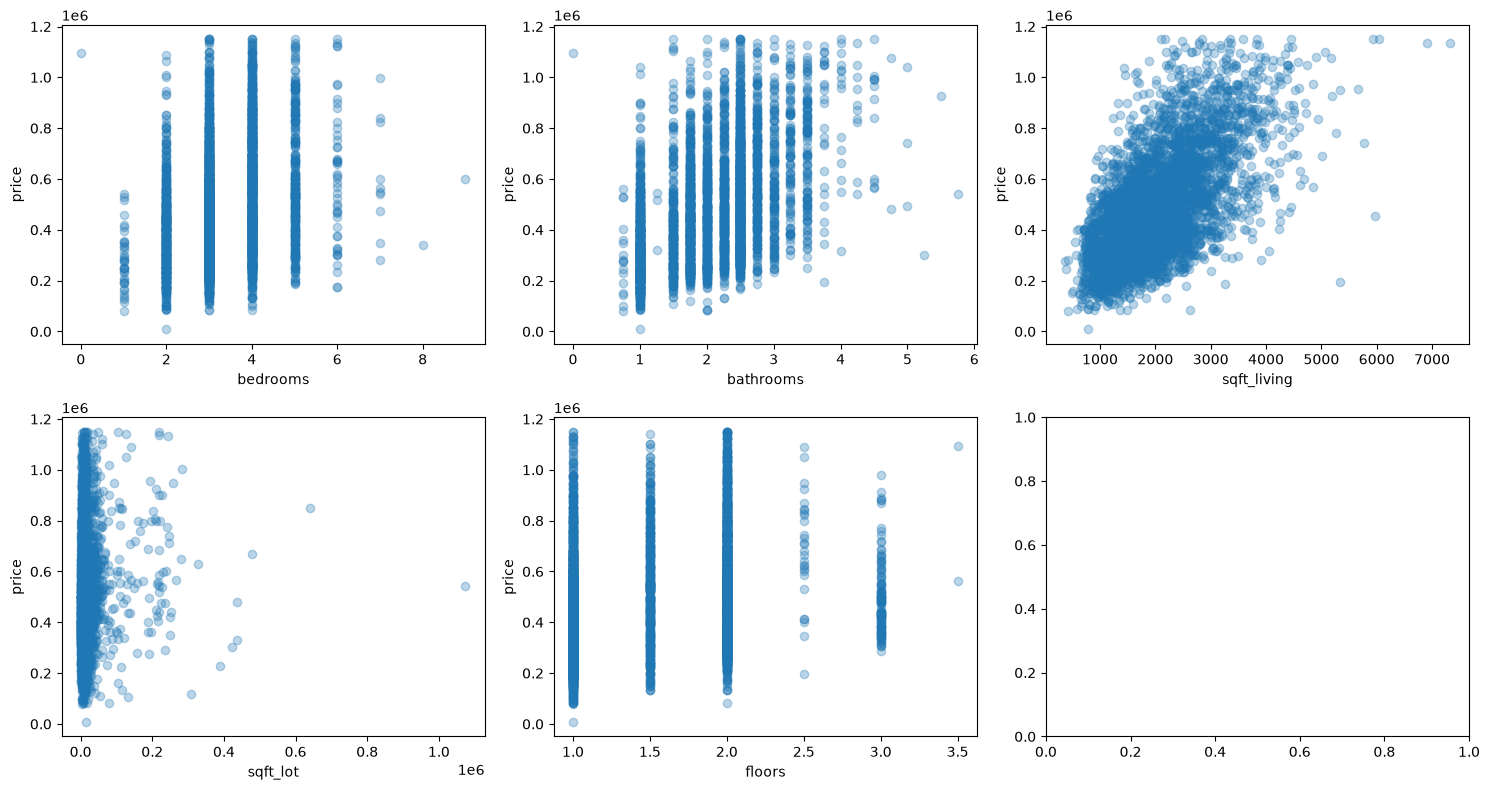

In [5]:
import matplotlib.pyplot as plt

features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    axes[i].scatter(df_clean[feature], df_clean['price'], alpha=0.3)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('price')

plt.tight_layout()
plt.show()

In [6]:
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors']

X = df_clean[features].copy()
y = df_clean['price'].values

# Standardize each feature
for col in features:
    X[col] = (X[col] - X[col].mean()) / X[col].std()

print(X.describe())

           bedrooms     bathrooms   sqft_living      sqft_lot        floors
count  4.311000e+03  4.311000e+03  4.311000e+03  4.311000e+03  4.311000e+03
mean   4.944626e-17 -4.944626e-18  8.405864e-17 -1.400977e-17  3.955701e-17
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min   -3.803452e+00 -2.928462e+00 -2.049895e+00 -3.862802e-01 -9.222028e-01
25%   -3.990611e-01 -4.814954e-01 -7.414759e-01 -2.655866e-01 -9.222028e-01
50%   -3.990611e-01  2.176379e-01 -1.366409e-01 -1.945872e-01  9.072972e-03
75%    7.357360e-01  5.672045e-01  5.916299e-01 -1.079684e-01  9.403488e-01
max    6.409721e+00  5.111571e+00  6.528888e+00  2.931895e+01  3.734176e+00


In [7]:
X_matrix = X.values   # convert DataFrame to plain NumPy array, shape (4311, 5)
y_vector = y           # already a NumPy array from before

print("X shape:", X_matrix.shape)
print("y shape:", y_vector.shape)

X shape: (4311, 5)
y shape: (4311,)


In [8]:
def batch_gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    n, num_features = X.shape
    weights = np.zeros(num_features)
    b = 0
    cost_history = []
    
    for i in range(epochs):
        y_pred = X @ weights + b
        error = y - y_pred
        cost = np.mean(error ** 2)
        cost_history.append(cost)
        
        gradient_weights = (-2/n) * (X.T @ error)
        gradient_b = (-2/n) * np.sum(error)
        
        weights = weights - learning_rate * gradient_weights
        b = b - learning_rate * gradient_b
        
        if i % 100 == 0:
            print(f"Epoch {i}: cost={cost:.2f}")
    
    return weights, b, cost_history

In [9]:
weights, b, cost_history = batch_gradient_descent(X_matrix, y_vector, learning_rate=0.01, epochs=1000)

print("Final weights:", weights)
print("Final bias:", b)

Epoch 0: cost=284112523513.30
Epoch 100: cost=32874463580.21
Epoch 200: cost=27847983209.74
Epoch 300: cost=27492465753.87
Epoch 400: cost=27397745976.65
Epoch 500: cost=27365352122.55
Epoch 600: cost=27353779022.61
Epoch 700: cost=27349562447.18
Epoch 800: cost=27348009121.26
Epoch 900: cost=27347433324.60
Final weights: [-23336.72577406   6733.13117178 142410.49535086  -6675.62487666
  12394.96486757]
Final bias: 487456.90108408564


In [ ]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=1000):
    n, num_features = X.shape
    weights = np.zeros(num_features)
    b = 0
    cost_history = []
    
    for i in range(epochs):
        # pick ONE random row
        random_index = np.random.randint(0, n)
        X_i = X[random_index]        # shape (5,) - just one house's features
        y_i = y[random_index]        # a single number - that house's price
        
        y_pred_i = X_i @ weights + b
        error_i = y_i - y_pred_i
        
        gradient_weights = -2 * X_i * error_i
        gradient_b = -2 * error_i
        
        weights = weights - learning_rate * gradient_weights
        b = b - learning_rate * gradient_b
        
        # Track cost on the FULL dataset periodically (not just this one point)
        if i % 100 == 0:
            y_pred_full = X @ weights + b
            cost = np.mean((y - y_pred_full) ** 2)
            cost_history.append(cost)
            print(f"Epoch {i}: cost={cost:.2f}")
    
    return weights, b, cost_history